# Análisis de viajes de taxi en Chicago

Proyecto de análisis exploratorio de datos y prueba de hipótesis para identificar patrones de demanda en empresas de taxi, zonas de destino y duración de viajes según condiciones climáticas.

**Herramientas:** Python, pandas, matplotlib, scipy, SQL y análisis estadístico.


Paso 4. Análisis exploratorio de datos

1. Importar librerías y cargar archivos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# Cargar los datasets
companies = pd.read_csv('/datasets/project_sql_result_01.csv')
dropoffs = pd.read_csv('/datasets/project_sql_result_04.csv')
trips = pd.read_csv('/datasets/project_sql_result_07.csv')

2. Estudiar los datos

In [3]:
# Primer vistazo al dataset de empresas de taxis
display(companies.head())

# Información general: columnas, tipos de datos y valores no nulos
companies.info()

# Estadísticas descriptivas de las columnas numéricas
display(companies.describe())

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


,trips_amount
count,64.000000
mean,2145.484375
std,3812.310186
min,2.000000
25%,20.750000
50%,178.500000
75%,2106.500000
max,19558.000000


In [4]:
# Primer vistazo al dataset de barrios de destino
display(dropoffs.head())

# Información general: columnas, tipos de datos y valores no nulos
dropoffs.info()

# Estadísticas descriptivas de las columnas numéricas
display(dropoffs.describe())

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


,average_trips
count,94.000000
mean,599.953728
std,1714.591098
min,1.800000
25%,14.266667
50%,52.016667
75%,298.858333
max,10727.466667


In [5]:
# Primer vistazo al dataset de viajes desde Loop hasta O'Hare
display(trips.head())

# Información general: columnas, tipos de datos y valores no nulos
trips.info()

# Estadísticas descriptivas de la duración de los viajes
display(trips.describe())

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


,duration_seconds
count,1068.000000
mean,2071.731273
std,769.461125
min,0.000000
25%,1438.250000
50%,1980.000000
75%,2580.000000
max,7440.000000


3. Revisar valores ausentes y duplicados

In [6]:
# Revisión de valores ausentes y duplicados en companies
print('Valores ausentes en companies:')
display(companies.isna().sum())

print('Duplicados en companies:', companies.duplicated().sum())

Valores ausentes en companies:


company_name    0
trips_amount    0
dtype: int64

Duplicados en companies: 0


In [7]:
# Revisión de valores ausentes y duplicados en dropoffs
print('Valores ausentes en dropoffs:')
display(dropoffs.isna().sum())

print('Duplicados en dropoffs:', dropoffs.duplicated().sum())

Valores ausentes en dropoffs:


dropoff_location_name    0
average_trips            0
dtype: int64

Duplicados en dropoffs: 0


In [8]:
# Revisión de valores ausentes y duplicados en trips
print('Valores ausentes en trips:')
display(trips.isna().sum())

print('Duplicados en trips:', trips.duplicated().sum())

Valores ausentes en trips:


start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64

Duplicados en trips: 197


No se encontraron valores ausentes en los tres datasets. En los archivos de empresas de taxi y barrios no se identificaron duplicados.

En el dataset de viajes sí aparecen registros duplicados. Sin embargo, no se eliminan porque cada fila representa un viaje registrado y no existe una columna identificadora única, como trip_id, que permita confirmar que se trata de duplicados reales. Es posible que varios viajes hayan tenido la misma hora de inicio, la misma condición climática y la misma duración. Eliminarlos sin una clave única podría borrar viajes válidos y sesgar el análisis.

4. Asegurar tipos de datos correctos

In [9]:
# Revisión de tipos de datos antes de hacer conversiones
print('Tipos de datos en companies:')
display(companies.dtypes)

print('Tipos de datos en dropoffs:')
display(dropoffs.dtypes)

print('Tipos de datos en trips:')
display(trips.dtypes)

Tipos de datos en companies:


company_name    object
trips_amount     int64
dtype: object

Tipos de datos en dropoffs:


dropoff_location_name     object
average_trips            float64
dtype: object

Tipos de datos en trips:


start_ts               object
weather_conditions     object
duration_seconds      float64
dtype: object

En este caso, start_ts debe convertirse a fecha y hora:

In [10]:
trips['start_ts'] = pd.to_datetime(trips['start_ts'])

In [11]:
# Verificamos que los viajes del dataset correspondan a sábado,
# ya que la hipótesis se refiere específicamente a viajes en sábado.
trips['weekday'] = trips['start_ts'].dt.day_name()

display(trips['weekday'].value_counts())

Saturday    1068
Name: weekday, dtype: int64

Se verificó el día de la semana de los registros del dataset de viajes. Todos los viajes corresponden a sábado, por lo que el archivo es consistente con la hipótesis planteada.

5. Identificar los 10 principales barrios por finalización de viajes

In [12]:
top_10_dropoffs = dropoffs.sort_values(by='average_trips', ascending=False).head(10)
top_10_dropoffs

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


Los barrios con mayor promedio de finalizaciones de viajes se concentran principalmente en zonas comerciales, turísticas y de alta actividad urbana. Loop ocupa el primer lugar, seguido por River North, Streeterville y West Loop. Esto tiene sentido porque son zonas con alta densidad de oficinas, hoteles, restaurantes, atracciones turísticas y conexiones de transporte. O'Hare también aparece dentro del top 10, lo cual es esperado por su importancia como aeropuerto internacional.

6. Gráfico: empresas de taxis y número de viajes

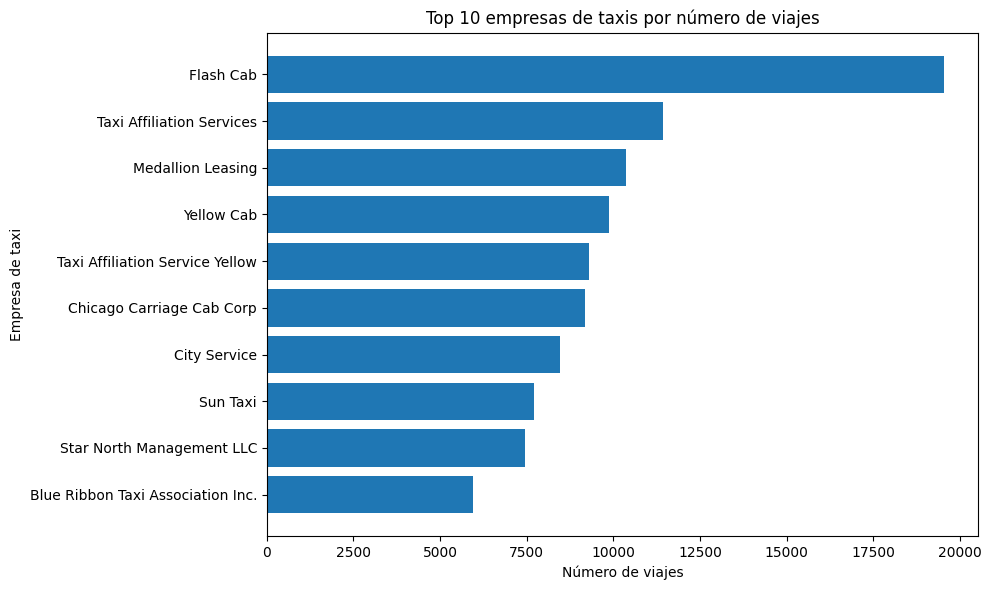

In [13]:
# Debido a que existen muchas empresas de taxis, se grafican las 10 principales
# para mejorar la legibilidad de la visualización.
top_companies = companies.sort_values(by='trips_amount', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_companies['company_name'], top_companies['trips_amount'])
plt.gca().invert_yaxis()
plt.title('Top 10 empresas de taxis por número de viajes')
plt.xlabel('Número de viajes')
plt.ylabel('Empresa de taxi')
plt.tight_layout()
plt.show()

Debido a que el dataset contiene muchas empresas de taxis, se graficaron las 10 principales para facilitar la interpretación.

Flash Cab es la empresa con mayor número de viajes durante el 15 y 16 de noviembre de 2017, con una ventaja clara sobre el resto. Le siguen Taxi Affiliation Services, Medallion Leasing y Yellow Cab. La distribución muestra que el volumen de viajes está concentrado en pocas empresas principales, mientras que muchas compañías tienen una participación mucho menor. Esto sugiere una estructura de mercado desigual, donde algunas empresas dominan la demanda registrada en esos días.

7. Gráfico: top 10 barrios por número promedio de finalizaciones

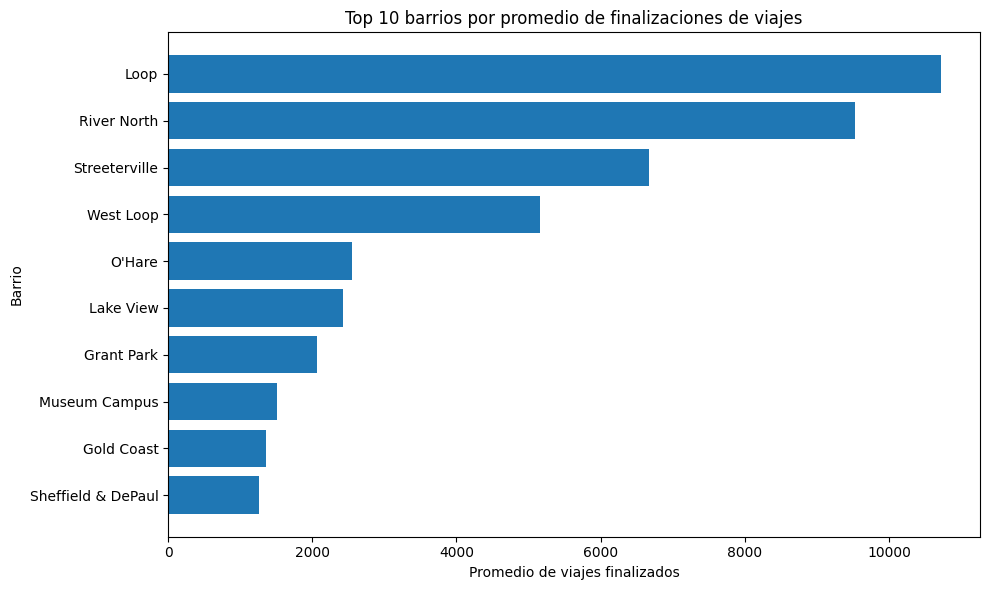

In [14]:
# Gráfico de los 10 barrios con mayor promedio de finalizaciones de viajes
plt.figure(figsize=(10, 6))
plt.barh(top_10_dropoffs['dropoff_location_name'], top_10_dropoffs['average_trips'])
plt.gca().invert_yaxis()
plt.title('Top 10 barrios por promedio de finalizaciones de viajes')
plt.xlabel('Promedio de viajes finalizados')
plt.ylabel('Barrio')
plt.tight_layout()
plt.show()

El gráfico confirma que Loop es el barrio con mayor promedio de viajes finalizados, seguido por River North, Streeterville y West Loop. Estos barrios corresponden a zonas céntricas y de alta actividad económica. La caída después de los primeros cuatro barrios es considerable, lo que indica que la demanda de taxis está fuertemente concentrada en ciertas áreas de Chicago. O'Hare aparece en quinto lugar, reflejando la importancia de los traslados hacia el aeropuerto.

Paso 5. Prueba de hipótesis

1. Revisar los datos del dataset de viajes

In [15]:
# Revisión inicial del dataset usado para la prueba de hipótesis
display(trips.head())

# Cantidad de viajes por condición climática
display(trips['weather_conditions'].value_counts())

,start_ts,weather_conditions,duration_seconds,weekday
0,2017-11-25 16:00:00,Good,2410.0,Saturday
1,2017-11-25 14:00:00,Good,1920.0,Saturday
2,2017-11-25 12:00:00,Good,1543.0,Saturday
3,2017-11-04 10:00:00,Good,2512.0,Saturday
4,2017-11-11 07:00:00,Good,1440.0,Saturday


Good    888
Bad     180
Name: weather_conditions, dtype: int64

In [16]:
# Estadísticas descriptivas de la duración de viajes según condición climática
display(trips.groupby('weather_conditions')['duration_seconds'].describe())

,count,mean,std,min,25%,50%,75%,max
weather_conditions,,,,,,,,
Bad,180.0,2427.205556,721.314138,480.0,1962.00,2540.0,2928.0,4980.0
Good,888.0,1999.675676,759.198268,0.0,1389.75,1800.0,2460.0,7440.0


2. Planteamiento de hipótesis

Hipótesis nula, H₀:

La duración promedio de los viajes desde el Loop hasta O'Hare es igual en sábados con buen clima y sábados lluviosos.

H₀: μ_good = μ_bad

Hipótesis alternativa, H₁:

La duración promedio de los viajes desde el Loop hasta O'Hare cambia en sábados lluviosos.

H₁: μ_good ≠ μ_bad

3. Definir nivel de significación

Se utiliza un nivel de significación de 0.05 porque es un criterio estándar en pruebas estadísticas. Esto significa que se acepta un 5% de probabilidad de rechazar la hipótesis nula cuando en realidad es verdadera.

In [17]:
alpha = 0.05

4. Crear las muestras

In [18]:
good_weather = trips[trips['weather_conditions'] == 'Good']['duration_seconds']
bad_weather = trips[trips['weather_conditions'] == 'Bad']['duration_seconds']

In [19]:
# Promedio de duración por grupo
print('Duración promedio con buen clima:', good_weather.mean())
print('Duración promedio con mal clima:', bad_weather.mean())

Duración promedio con buen clima: 1999.6756756756756
Duración promedio con mal clima: 2427.2055555555557


5. Probar igualdad de varianzas

Se utiliza una prueba t para muestras independientes porque se comparan las medias de duración de dos grupos distintos de viajes: viajes con buen clima y viajes con clima malo.

In [20]:
# Prueba de Levene para comparar las varianzas de ambos grupos
levene_result = stats.levene(good_weather, bad_weather)

print('p-value Levene:', levene_result.pvalue)

p-value Levene: 0.5332038671974493


Para decidir cómo aplicar la prueba t, primero se utilizó la prueba de Levene para comparar las varianzas de ambos grupos.

La hipótesis nula de Levene plantea que las varianzas son iguales. Como el valor p de Levene es mayor que 0.05, no se rechaza la hipótesis de igualdad de varianzas. Por lo tanto, se aplica la prueba t para muestras independientes usando equal_var=True.

6. Aplicar prueba t

In [21]:
# Prueba t para muestras independientes
# Se usa equal_var=True porque la prueba de Levene no mostró evidencia
# suficiente para considerar diferentes las varianzas.
results = stats.ttest_ind(good_weather, bad_weather, equal_var=True)

print('p-value:', results.pvalue)

p-value: 6.517970327099473e-12


In [22]:
if results.pvalue < alpha:
    print('Rechazamos la hipótesis nula')
else:
    print('No podemos rechazar la hipótesis nula')

Rechazamos la hipótesis nula


7. Conclusión de la prueba de hipótesis

Con un nivel de significación de 0.05, el valor p de la prueba t fue mucho menor que alfa. Por lo tanto, se rechaza la hipótesis nula.

Existe evidencia estadísticamente significativa para concluir que la duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare es diferente entre sábados con buen clima y sábados con clima malo.

Además, la duración promedio de los viajes con clima malo fue de aproximadamente 2427 segundos, mientras que con buen clima fue de aproximadamente 2000 segundos. Esto indica que, en promedio, los viajes en condiciones climáticas malas duran más.

La diferencia observada está asociada a las condiciones climáticas, aunque no debe interpretarse como una prueba causal absoluta, ya que otros factores como tráfico, hora del día o demanda también podrían influir en la duración del viaje.

Conclusión general del proyecto

El análisis exploratorio mostró que el mercado de taxis en Chicago está concentrado en pocas empresas. Flash Cab lidera claramente el número de viajes registrados durante el 15 y 16 de noviembre de 2017, seguida por Taxi Affiliation Services, Medallion Leasing y Yellow Cab. Esto sugiere que algunas empresas tienen una participación mucho mayor en la demanda de viajes.

También se observó que los viajes finalizan con mayor frecuencia en barrios céntricos y de alta actividad económica como Loop, River North, Streeterville y West Loop. Estos barrios concentran oficinas, zonas comerciales, restaurantes, hoteles y atracciones turísticas, por lo que es razonable que tengan un mayor promedio de finalizaciones de viajes. O'Hare también aparece dentro de los principales barrios de destino, lo cual refleja la importancia de los traslados hacia el aeropuerto.

En la prueba de hipótesis, se comparó la duración promedio de los viajes desde Loop hasta el Aeropuerto Internacional O'Hare entre sábados con buen clima y sábados con clima malo. Con un nivel de significación de 0.05, el valor p fue menor que alfa, por lo que se rechazó la hipótesis nula. Esto indica que existe una diferencia estadísticamente significativa entre ambos grupos.

En promedio, los viajes en condiciones climáticas malas tuvieron una mayor duración que los viajes en condiciones climáticas buenas. Esta diferencia puede estar relacionada con tráfico más lento, menor velocidad de circulación, mayor precaución al manejar o afectaciones viales por lluvia o tormenta. Sin embargo, el análisis permite identificar una diferencia estadísticamente significativa asociada al clima, no demostrar causalidad absoluta.